In [1]:
# Libs
from time import gmtime, strftime
import xarray as xr
import numpy as np

# Locals
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
import oggm.cfg as cfg
from oggm.shop import gcm_climate

In [2]:
# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='WARNING')

# change border around the individual glaciers
cfg.PARAMS['border'] = 80

# Use Multiprocessing
cfg.PARAMS['use_multiprocessing'] = True

# For hydro output
cfg.PARAMS['store_model_geometry'] = True

# Local working directory (where OGGM will write its output)
cfg.PATHS['working_dir'] = '/home/usman/Music/GeeMap/OGGM/data'

# RGI glaciers: Chhateboi Glacier,Chllinji Glacier,Koz Yaz Glacier,Pekhin Glacier,Karambar Glacier
rgi_ids = utils.get_rgi_glacier_entities(['RGI60-14.02192','RGI60-14.01226','RGI60-14.01893','RGI60-14.01454','RGI60-14.01489',
                                          'RGI60-14.02765','RGI60-14.03035','RGI60-14.01922','RGI60-14.01586','RGI60-14.01391',
                                          'RGI60-14.01400','RGI60-14.01277','RGI60-14.01204','RGI60-14.01291','RGI60-14.01202'])

# Go - get the pre-processed glacier directories
# in OGGM v1.6 you have to explicitly indicate the url from where you want to start from
# we will use here the elevation band flowlines which are much simpler than the centerlines
gdirs = workflow.init_glacier_directories(rgi_ids, from_prepro_level=5, prepro_base_url=DEFAULT_BASE_URL)

2025-01-09 11:06:12: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-01-09 11:06:12: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-01-09 11:06:12: oggm.cfg: Multiprocessing: using all available processors (N=16)
2025-01-09 11:06:12: oggm.cfg: Multiprocessing switched ON after user settings.
2025-01-09 11:06:12: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-01-09 11:06:15: oggm.workflow: init_glacier_directories from prepro level 5 on 15 glaciers.
2025-01-09 11:06:15: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 15 glaciers


In [4]:
gdirs

[<oggm.GlacierDirectory>
   RGI id: RGI60-14.01202
   Region: 14: South Asia West
   Subregion: 14-02: Karakoram                       
   Glacier type: Glacier
   Terminus type: Land-terminating
   Status: Glacier or ice cap
   Area: 3.528 km2
   Lon, Lat: (73.717, 36.8395)
   Grid (nx, ny): (235, 265)
   Grid (dx, dy): (36.0, -36.0),
 <oggm.GlacierDirectory>
   RGI id: RGI60-14.01204
   Region: 14: South Asia West
   Subregion: 14-02: Karakoram                       
   Glacier type: Glacier
   Terminus type: Land-terminating
   Status: Glacier or ice cap
   Area: 1.137 km2
   Lon, Lat: (73.7945, 36.8394)
   Grid (nx, ny): (205, 251)
   Grid (dx, dy): (25.0, -25.0),
 <oggm.GlacierDirectory>
   RGI id: RGI60-14.01226
   Region: 14: South Asia West
   Subregion: 14-02: Karakoram                       
   Name: Chhateboi Glacier
   Glacier type: Glacier
   Terminus type: Land-terminating
   Status: Glacier or ice cap
   Area: 35.674 km2
   Lon, Lat: (73.8878, 36.7795)
   Grid (nx, ny): 

In [5]:
import csv
import pandas as pd

# Extract data from gdirs
data = []
for gdir in gdirs:
    data.append({
        'RGI_id': gdir.rgi_id,
        'Region': gdir.rgi_region,
        'Subregion': gdir.rgi_subregion,
        'Name': gdir.name,
        'Terminus_type': gdir.terminus_type,
        'Status': gdir.status,
        'Area_km2': gdir.rgi_area_km2,
        'Lon': gdir.cenlon,
        'Lat': gdir.cenlat
    })

# Convert to DataFrame
df = pd.DataFrame(data)

# Save to CSV
csv_path = 'gdirs_data.csv'  # Update with your desired path
df.to_csv(csv_path, index=False)
print(f"gdirs data saved to {csv_path}")


gdirs data saved to gdirs_data.csv


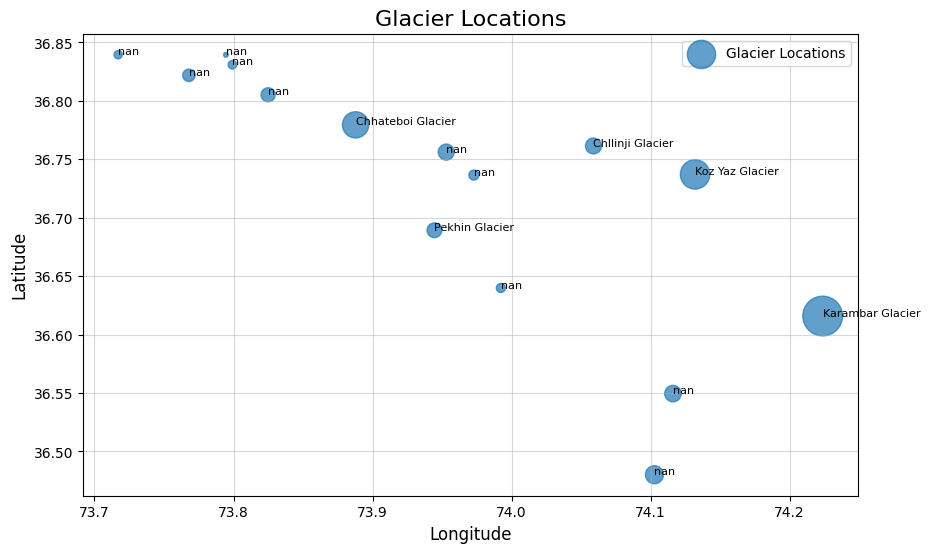

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV data
df = pd.read_csv('gdirs_data.csv')

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Lon'], df['Lat'], s=df['Area_km2'] * 10, alpha=0.7, label='Glacier Locations')
for i, name in enumerate(df['Name']):
    plt.text(df['Lon'][i], df['Lat'][i], name, fontsize=8)

# Customize the plot
plt.title('Glacier Locations', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(alpha=0.5)
plt.legend()
plt.savefig('/home/usman/Music/GeeMap/Results/glacier.png', dpi=500, bbox_inches='tight')
plt.show()


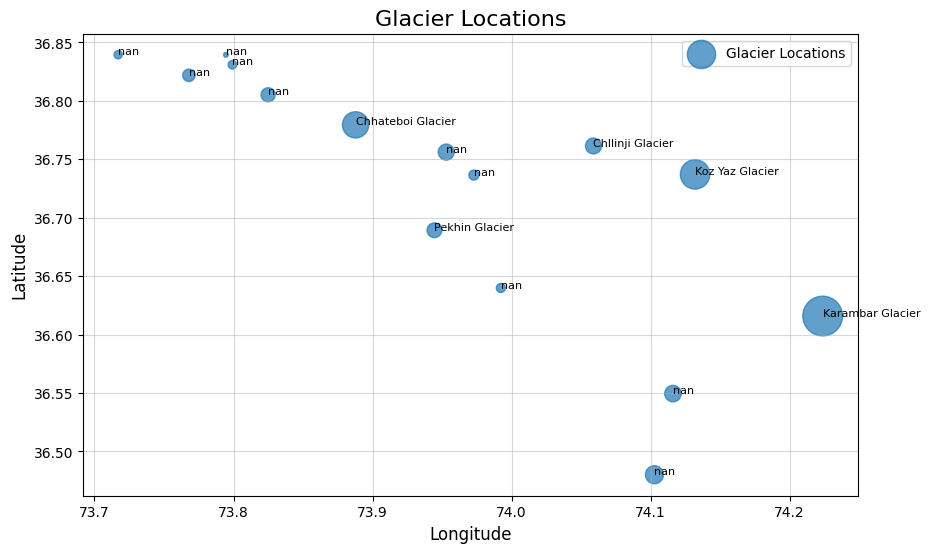

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV data
df = pd.read_csv('gdirs_data.csv')

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Lon'], df['Lat'], s=df['Area_km2'] * 10, alpha=0.7, label='Glacier Locations')
for i, name in enumerate(df['Name']):
    plt.text(df['Lon'][i], df['Lat'][i], name, fontsize=8)

# Customize the plot
plt.title('Glacier Locations', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(alpha=0.5)
plt.legend()
plt.show()


In [8]:
gdirs

[<oggm.GlacierDirectory>
   RGI id: RGI60-14.01202
   Region: 14: South Asia West
   Subregion: 14-02: Karakoram                       
   Glacier type: Glacier
   Terminus type: Land-terminating
   Status: Glacier or ice cap
   Area: 3.528 km2
   Lon, Lat: (73.717, 36.8395)
   Grid (nx, ny): (235, 265)
   Grid (dx, dy): (36.0, -36.0),
 <oggm.GlacierDirectory>
   RGI id: RGI60-14.01204
   Region: 14: South Asia West
   Subregion: 14-02: Karakoram                       
   Glacier type: Glacier
   Terminus type: Land-terminating
   Status: Glacier or ice cap
   Area: 1.137 km2
   Lon, Lat: (73.7945, 36.8394)
   Grid (nx, ny): (205, 251)
   Grid (dx, dy): (25.0, -25.0),
 <oggm.GlacierDirectory>
   RGI id: RGI60-14.01226
   Region: 14: South Asia West
   Subregion: 14-02: Karakoram                       
   Name: Chhateboi Glacier
   Glacier type: Glacier
   Terminus type: Land-terminating
   Status: Glacier or ice cap
   Area: 35.674 km2
   Lon, Lat: (73.8878, 36.7795)
   Grid (nx, ny): 

In [9]:
all_GCM = ['gfdl-esm4_r1i1p1f1', 'ipsl-cm6a-lr_r1i1p1f1',
           'mpi-esm1-2-hr_r1i1p1f1',
           'mri-esm2-0_r1i1p1f1', 'ukesm1-0-ll_r1i1p1f2']

# define the SSP scenarios
all_scenario = ['ssp126', 'ssp370', 'ssp585']

for GCM in all_GCM:
    for ssp in all_scenario:
        # we will pretend that 'mpi-esm1-2-hr_r1i1p1f1' is missing for `ssp370`
        # to later show how to deal with missing values, 
        # if you want to use this
        # code you can of course remove the "if" and just download all GCMs and SSPS 
        # if (ssp == 'ssp370') & (GCM=='mpi-esm1-2-hr_r1i1p1f1'):
        #     pass
        # else:
            # Download and process them:
            workflow.execute_entity_task(gcm_climate.process_monthly_isimip_data, gdirs, 
                                         ssp = ssp,
                                         # gcm ensemble -> you can choose another one
                                         member=GCM,
                                         # recognize the climate file for later
                                         output_filesuffix=f'_{GCM}_{ssp}'
                                         );
            
# you could create a similar workflow with CMIP5 or CMIP6 

2025-01-09 11:26:26: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 15 glaciers
2025-01-09 11:26:28: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 15 glaciers
2025-01-09 11:26:31: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 15 glaciers
2025-01-09 11:26:33: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 15 glaciers
2025-01-09 11:26:36: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 15 glaciers
2025-01-09 11:26:38: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 15 glaciers
2025-01-09 11:26:41: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 15 glaciers
2025-01-09 11:26:44: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 15 glaciers
2025-01-09 11:26:46: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 15 glaciers
2025-01-09 11:26:49: oggm.workflow: Execute entity tasks [process_monthly_isimip_d

In [10]:
for GCM in all_GCM:
    for scen in all_scenario:
        rid = '_{}_{}'.format(GCM, scen)
        try:  # check if (GCM, scen) combination exists
            workflow.execute_entity_task(tasks.run_with_hydro, gdirs,
                                         run_task=tasks.run_from_climate_data,
                                         ys=2015,  # star year of our projection runs
                                         climate_filename='gcm_data',  # use gcm_data, not climate_historical
                                         climate_input_filesuffix=rid,  # use the chosen GCM and scenario
                                         init_model_filesuffix='_spinup_historical',  # this is important! Start from 2020 glacier
                                         output_filesuffix=rid,  # the filesuffix of the resulting file, so we can find it later
                                         store_monthly_hydro=True
                                        );

        except FileNotFoundError:
            # if a certain scenario is not available for a GCM we land here
            # and we inidcate this by printing a message so the user knows
            # this scenario is missing
            # (in this case of course, the file actually is available, but we just pretend that it is not...)
            print('No ' + GCM +' run with scenario ' + scen + ' available!')

2025-01-09 11:34:01: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:03: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:04: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:06: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:07: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:09: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:11: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:12: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:14: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:15: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:17: oggm.workflow: Execute entity tasks [run_with_hydro] on 15 glaciers
2025-01-09 11:34:19: 

In [11]:
file_id  = '_{}_{}'.format(all_GCM[0], all_scenario[0])
ds = utils.compile_run_output(gdirs, input_filesuffix=file_id)
ds

2025-01-09 11:34:39: oggm.utils: Applying global task compile_run_output on 15 glaciers
2025-01-09 11:34:39: oggm.utils: Applying compile_run_output on 15 gdirs.


<xarray.Dataset> Size: 913kB
Dimensions:                       (time: 87, rgi_id: 15, month_2d: 12)
Coordinates:
  * time                          (time) float64 696B 2.015e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 840B 'RGI60-14.01202' ... 'RG...
    hydro_year                    (time) int64 696B 2015 2016 2017 ... 2100 2101
    hydro_month                   (time) int64 696B 4 4 4 4 4 4 ... 4 4 4 4 4 4
    calendar_year                 (time) int64 696B 2015 2016 2017 ... 2100 2101
    calendar_month                (time) int64 696B 1 1 1 1 1 1 ... 1 1 1 1 1 1
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
Data variables: (12/24)
    volume                        (time, rgi_id) float64 10kB 1.777e+08 ... 9...
    volume_bsl                    (time, rgi_id) float64 10kB 0.0 0.0 ... 0.0
    volume_bwl                    (time, rgi_id) float64 10kB 0.0 0.0 ... 0.0
    area                          (time, rgi_id) float64 10kB 3.517e+06 ... 1...
    length                        (time, rgi_id) float64 10kB 3.888e+03 ... 5...
    calving                       (time, rgi_id) float64 10kB 0.0 0.0 ... 0.0
    ...                            ...
    liq_prcp_on_glacier_monthly   (time, month_2d, rgi_id) float64 125kB 0.0 ...
    snowfall_off_glacier_monthly  (time, month_2d, rgi_id) float64 125kB 2.65...
    snowfall_on_glacier_monthly   (time, month_2d, rgi_id) float64 125kB 1.47...
    water_level                   (rgi_id) float64 120B 0.0 0.0 0.0 ... 0.0 0.0
    glen_a                        (rgi_id) float64 120B 6.43e-24 ... 7.137e-24
    fs                            (rgi_id) float64 120B 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.2
    calendar:       365-day no leap
    creation_date:  2025-01-09 06:34:40

In [7]:
ds['volume'].loc[{'time': [2030, 2040], 'rgi_id': ['RGI60-14.02192' ]}]

<xarray.DataArray 'volume' (time: 2, rgi_id: 1)> Size: 16B
array([[7.40399624e+09],
       [7.32354753e+09]])
Coordinates:
  * time            (time) float64 16B 2.03e+03 2.04e+03
  * rgi_id          (rgi_id) <U14 56B 'RGI60-14.02192'
    hydro_year      (time) int64 16B 2030 2040
    hydro_month     (time) int64 16B 4 4
    calendar_year   (time) int64 16B 2030 2040
    calendar_month  (time) int64 16B 1 1
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [12]:
ds.coords['GCM'] = all_GCM[0]
ds.coords['GCM'].attrs['description'] = 'Global Circulation Model'
ds

<xarray.Dataset> Size: 913kB
Dimensions:                       (time: 87, rgi_id: 15, month_2d: 12)
Coordinates:
  * time                          (time) float64 696B 2.015e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 840B 'RGI60-14.01202' ... 'RG...
    hydro_year                    (time) int64 696B 2015 2016 2017 ... 2100 2101
    hydro_month                   (time) int64 696B 4 4 4 4 4 4 ... 4 4 4 4 4 4
    calendar_year                 (time) int64 696B 2015 2016 2017 ... 2100 2101
    calendar_month                (time) int64 696B 1 1 1 1 1 1 ... 1 1 1 1 1 1
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    GCM                           <U18 72B 'gfdl-esm4_r1i1p1f1'
Data variables: (12/24)
    volume                        (time, rgi_id) float64 10kB 1.777e+08 ... 9...
    volume_bsl                    (time, rgi_id) float64 10kB 0.0 0.0 ... 0.0
    volume_bwl                    (time, rgi_id) float64 10kB 0.0 0.0 ... 0.0
    area                          (time, rgi_id) float64 10kB 3.517e+06 ... 1...
    length                        (time, rgi_id) float64 10kB 3.888e+03 ... 5...
    calving                       (time, rgi_id) float64 10kB 0.0 0.0 ... 0.0
    ...                            ...
    liq_prcp_on_glacier_monthly   (time, month_2d, rgi_id) float64 125kB 0.0 ...
    snowfall_off_glacier_monthly  (time, month_2d, rgi_id) float64 125kB 2.65...
    snowfall_on_glacier_monthly   (time, month_2d, rgi_id) float64 125kB 1.47...
    water_level                   (rgi_id) float64 120B 0.0 0.0 0.0 ... 0.0 0.0
    glen_a                        (rgi_id) float64 120B 6.43e-24 ... 7.137e-24
    fs                            (rgi_id) float64 120B 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.2
    calendar:       365-day no leap
    creation_date:  2025-01-09 06:34:40

In [13]:
ds = ds.expand_dims('GCM')
ds

<xarray.Dataset> Size: 913kB
Dimensions:                       (time: 87, rgi_id: 15, month_2d: 12, GCM: 1)
Coordinates:
  * time                          (time) float64 696B 2.015e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 840B 'RGI60-14.01202' ... 'RG...
    hydro_year                    (time) int64 696B 2015 2016 2017 ... 2100 2101
    hydro_month                   (time) int64 696B 4 4 4 4 4 4 ... 4 4 4 4 4 4
    calendar_year                 (time) int64 696B 2015 2016 2017 ... 2100 2101
    calendar_month                (time) int64 696B 1 1 1 1 1 1 ... 1 1 1 1 1 1
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
  * GCM                           (GCM) <U18 72B 'gfdl-esm4_r1i1p1f1'
Data variables: (12/24)
    volume                        (GCM, time, rgi_id) float64 10kB 1.777e+08 ...
    volume_bsl                    (GCM, time, rgi_id) float64 10kB 0.0 ... 0.0
    volume_bwl                    (GCM, time, rgi_id) float64 10kB 0.0 ... 0.0
    area                          (GCM, time, rgi_id) float64 10kB 3.517e+06 ...
    length                        (GCM, time, rgi_id) float64 10kB 3.888e+03 ...
    calving                       (GCM, time, rgi_id) float64 10kB 0.0 ... 0.0
    ...                            ...
    liq_prcp_on_glacier_monthly   (GCM, time, month_2d, rgi_id) float64 125kB ...
    snowfall_off_glacier_monthly  (GCM, time, month_2d, rgi_id) float64 125kB ...
    snowfall_on_glacier_monthly   (GCM, time, month_2d, rgi_id) float64 125kB ...
    water_level                   (GCM, rgi_id) float64 120B 0.0 0.0 ... 0.0 0.0
    glen_a                        (GCM, rgi_id) float64 120B 6.43e-24 ... 7.1...
    fs                            (GCM, rgi_id) float64 120B 0.0 0.0 ... 0.0 0.0
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.2
    calendar:       365-day no leap
    creation_date:  2025-01-09 06:34:40

In [14]:
ds_all = []  # in this array all datasets going to be stored with additional coordinates GCM and SCENARIO
creation_date = strftime("%Y-%m-%d %H:%M:%S", gmtime())  # here add the current time for info
for GCM in all_GCM:  # loop through all GCMs
    for scen in all_scenario:  # loop through all SSPs
        try:  # check if GCM, SCENARIO combination exists
            rid = '_{}_{}'.format(GCM, scen)  # put together the same filesuffix which was used during the projection runs

            ds_tmp = utils.compile_run_output(gdirs, input_filesuffix=rid)  # open one model run

            ds_tmp.coords['GCM'] = GCM  # add GCM as a coordinate
            ds_tmp.coords['GCM'].attrs['description'] = 'used Global circulation Model'  # add a description for GCM
            ds_tmp = ds_tmp.expand_dims("GCM")  # add GCM as a dimension to all Data variables

            ds_tmp.coords['SCENARIO'] = scen  # add scenario (here ssp) as a coordinate
            ds_tmp.coords['SCENARIO'].attrs['description'] = 'used scenario (here SSPs)'
            ds_tmp = ds_tmp.expand_dims("SCENARIO")  # add SSO as a dimension to all Data variables

            ds_tmp.attrs['creation_date'] = creation_date  # also add todays date for info
            ds_all.append(ds_tmp)  # add the dataset with extra coordinates to our final ds_all array

        except RuntimeError as err:  # here we land if an error occured
            if str(err) == 'Found no valid glaciers!':  # This is the error message if the GCM, SCENARIO (here ssp) combination does not exist
                print(f'No data for GCM {GCM} with SCENARIO {scen} found!')  # print a descriptive message
            else:
                raise RuntimeError(err)  # if an other error occured we just raise it

2025-01-09 11:36:16: oggm.utils: Applying global task compile_run_output on 15 glaciers
2025-01-09 11:36:16: oggm.utils: Applying compile_run_output on 15 gdirs.
2025-01-09 11:36:16: oggm.utils: Applying global task compile_run_output on 15 glaciers
2025-01-09 11:36:16: oggm.utils: Applying compile_run_output on 15 gdirs.
2025-01-09 11:36:17: oggm.utils: Applying global task compile_run_output on 15 glaciers
2025-01-09 11:36:17: oggm.utils: Applying compile_run_output on 15 gdirs.
2025-01-09 11:36:17: oggm.utils: Applying global task compile_run_output on 15 glaciers
2025-01-09 11:36:17: oggm.utils: Applying compile_run_output on 15 gdirs.
2025-01-09 11:36:17: oggm.utils: Applying global task compile_run_output on 15 glaciers
2025-01-09 11:36:17: oggm.utils: Applying compile_run_output on 15 gdirs.
2025-01-09 11:36:18: oggm.utils: Applying global task compile_run_output on 15 glaciers
2025-01-09 11:36:18: oggm.utils: Applying compile_run_output on 15 gdirs.
2025-01-09 11:36:18: oggm.ut

In [15]:
ds_all

[<xarray.Dataset> Size: 913kB
 Dimensions:                       (time: 87, rgi_id: 15, month_2d: 12,
                                    SCENARIO: 1, GCM: 1)
 Coordinates:
   * time                          (time) float64 696B 2.015e+03 ... 2.101e+03
   * rgi_id                        (rgi_id) <U14 840B 'RGI60-14.01202' ... 'RG...
     hydro_year                    (time) int64 696B 2015 2016 2017 ... 2100 2101
     hydro_month                   (time) int64 696B 4 4 4 4 4 4 ... 4 4 4 4 4 4
     calendar_year                 (time) int64 696B 2015 2016 2017 ... 2100 2101
     calendar_month                (time) int64 696B 1 1 1 1 1 1 ... 1 1 1 1 1 1
   * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
     calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
   * GCM                           (GCM) <U18 72B 'gfdl-esm4_r1i1p1f1'
   * SCENARIO                      (SCENARIO) <U6 24B 'ssp126'
 Data variables: (12/24)
     volume        

In [16]:
ds_merged = xr.combine_by_coords(ds_all, fill_value=np.nan)  # define how the missing GCM, SCENARIO combinations should be filled

In [36]:
ds_merged

<xarray.Dataset> Size: 14MB
Dimensions:                       (SCENARIO: 3, GCM: 5, time: 87, rgi_id: 15,
                                   month_2d: 12)
Coordinates:
  * time                          (time) float64 696B 2.015e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 840B 'RGI60-14.01202' ... 'RG...
    hydro_year                    (time) int64 696B ...
    hydro_month                   (time) int64 696B ...
    calendar_year                 (time) int64 696B ...
    calendar_month                (time) int64 696B ...
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B ...
  * GCM                           (GCM) <U22 440B 'gfdl-esm4_r1i1p1f1' ... 'u...
  * SCENARIO                      (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Data variables: (12/24)
    volume                        (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    volume_bsl                    (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    volume_bwl                    (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    area                          (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    length                        (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    calving                       (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    ...                            ...
    liq_prcp_on_glacier_monthly   (SCENARIO, GCM, time, month_2d, rgi_id) float64 2MB ...
    snowfall_off_glacier_monthly  (SCENARIO, GCM, time, month_2d, rgi_id) float64 2MB ...
    snowfall_on_glacier_monthly   (SCENARIO, GCM, time, month_2d, rgi_id) float64 2MB ...
    water_level                   (SCENARIO, GCM, rgi_id) float64 2kB ...
    glen_a                        (SCENARIO, GCM, rgi_id) float64 2kB ...
    fs                            (SCENARIO, GCM, rgi_id) float64 2kB ...
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.2
    calendar:       365-day no leap
    creation_date:  2025-01-09 06:36:16

In [17]:
ds_merged.to_netcdf('/home/usman/Music/GeeMap/Results/15_GCM_projections.nc')

In [18]:
ds_merged.to_netcdf('merged_GCM_projections.nc')

In [19]:
with xr.open_dataset('merged_GCM_projections.nc') as ds:
    ds_merged = ds

In [37]:
# List all variables in the dataset
print(ds_merged.variables)

Frozen({'volume': <xarray.Variable (SCENARIO: 3, GCM: 5, time: 87, rgi_id: 15)> Size: 157kB
array([[[[1.777296e+08, ..., 1.110987e+09],
         ...,
         [1.851192e+07, ..., 9.141848e+08]],

        ...,

        [[1.777296e+08, ..., 1.110987e+09],
         ...,
         [5.982298e+06, ..., 7.095846e+08]]],


       ...,


       [[[1.777296e+08, ..., 1.110987e+09],
         ...,
         [1.736590e+05, ..., 5.866691e+08]],

        ...,

        [[1.777296e+08, ..., 1.110987e+09],
         ...,
         [0.000000e+00, ..., 2.571887e+06]]]], shape=(3, 5, 87, 15))
Attributes:
    description:  Total glacier volume
    unit:         m 3, 'volume_bsl': <xarray.Variable (SCENARIO: 3, GCM: 5, time: 87, rgi_id: 15)> Size: 157kB
[19575 values with dtype=float64]
Attributes:
    description:  Glacier volume below sea-level
    unit:         m 3, 'volume_bwl': <xarray.Variable (SCENARIO: 3, GCM: 5, time: 87, rgi_id: 15)> Size: 157kB
[19575 values with dtype=float64]
Attributes:
    descrip

In [38]:
# the missing values were filled with np.NaN values for all time points and glaciers 
assert np.all(np.isnan(ds_merged['volume'].sel(SCENARIO='ssp370').sel(GCM='mpi-esm1-2-hr_r1i1p1f1')))

AssertionError: 

In [67]:
mask = ~np.isnan(ds_merged['volume'].sel(SCENARIO='ssp370', GCM='mpi-esm1-2-hr_r1i1p1f1').values)
non_nan_indices = np.where(mask)
print("Non-NaN values found at:", non_nan_indices)


Non-NaN values found at: (array([ 0,  0,  0, ..., 86, 86, 86], shape=(1305,)), array([ 0,  1,  2, ..., 12, 13, 14], shape=(1305,)))


ERROR:tornado.application:Uncaught exception GET /ws (::1)
HTTPServerRequest(protocol='http', host='localhost:43483', method='GET', uri='/ws', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "/home/usman/anaconda3/envs/oggm_env/lib/python3.10/site-packages/tornado/websocket.py", line 938, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/home/usman/anaconda3/envs/oggm_env/lib/python3.10/site-packages/tornado/web.py", line 3301, in wrapper
    return method(self, *args, **kwargs)
  File "/home/usman/anaconda3/envs/oggm_env/lib/python3.10/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-token-expiration if necessary


In [39]:
# So, what happens to the missing GCM and ssp if we just do the sum? 
ds_total_volume_wrong = ds_merged['volume'].sum(dim='rgi_id',  # over which dimension the sum should be taken, here we want to sum up over all glacier ids
                                          keep_attrs=True)  # keep the variable descriptions       
ds_total_volume_wrong.sel(SCENARIO='ssp370').sel(GCM='mpi-esm1-2-hr_r1i1p1f1')

<xarray.DataArray 'volume' (time: 87)> Size: 696B
array([2.28378759e+10, 2.26102241e+10, 2.26312759e+10, 2.24940260e+10,
       2.25693904e+10, 2.24331608e+10, 2.23773531e+10, 2.23190416e+10,
       2.21496565e+10, 2.19860087e+10, 2.16756859e+10, 2.16205398e+10,
       2.15207843e+10, 2.12810716e+10, 2.10607833e+10, 2.09181697e+10,
       2.08541785e+10, 2.08390429e+10, 2.06555432e+10, 2.05949800e+10,
       2.05693206e+10, 2.06082652e+10, 2.05419809e+10, 2.04321334e+10,
       2.06019937e+10, 2.05941629e+10, 2.04840569e+10, 2.01600367e+10,
       1.99408766e+10, 1.99787448e+10, 1.98338417e+10, 1.96269374e+10,
       1.95195561e+10, 1.94899490e+10, 1.90985589e+10, 1.89327768e+10,
       1.89340029e+10, 1.88842631e+10, 1.88848361e+10, 1.88002167e+10,
       1.85878750e+10, 1.84640846e+10, 1.83518474e+10, 1.83586581e+10,
       1.81274304e+10, 1.79276141e+10, 1.78516317e+10, 1.75514579e+10,
       1.74965614e+10, 1.74284239e+10, 1.70898515e+10, 1.68557437e+10,
       1.66750834e+10, 1.65134591e+10, 1.63721293e+10, 1.61215718e+10,
       1.59062760e+10, 1.57425134e+10, 1.56071920e+10, 1.55386181e+10,
       1.54919552e+10, 1.52488710e+10, 1.50199678e+10, 1.46644699e+10,
       1.44137338e+10, 1.41871129e+10, 1.39109973e+10, 1.36734294e+10,
       1.36123970e+10, 1.34833548e+10, 1.32474940e+10, 1.30416019e+10,
       1.30365430e+10, 1.27387536e+10, 1.26120008e+10, 1.24815953e+10,
       1.21579975e+10, 1.18500218e+10, 1.16675847e+10, 1.13771604e+10,
       1.12636504e+10, 1.10639028e+10, 1.07775068e+10, 1.04710043e+10,
       1.02739747e+10, 1.00697664e+10, 9.80586231e+09])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
    GCM             <U22 88B 'mpi-esm1-2-hr_r1i1p1f1'
    SCENARIO        <U6 24B 'ssp370'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [40]:
ds_total_volume = ds_merged['volume'].sum(dim='rgi_id',  # over which dimension the sum should be taken, here we want to sum up over all glacier ids
                                          skipna=True,  # ignore nan values
                                          # important, we need values for every glacier (here 2) to do the sum
                                          # if some have NaN, the sum should also be NaN (if you don't set min_count, the sum will be 0, which is bad)
                                          min_count=len(ds_merged.rgi_id), 
                                          keep_attrs=True)  # keep the variable descriptions   
# perfect, now, the `NaN` is preserved!
assert np.all(np.isnan(ds_total_volume.sel(SCENARIO='ssp370').sel(GCM='mpi-esm1-2-hr_r1i1p1f1')))

AssertionError: 

In [41]:
ds_total_volume

<xarray.DataArray 'volume' (SCENARIO: 3, GCM: 5, time: 87)> Size: 10kB
array([[[2.28378759e+10, 2.27093644e+10, 2.24062053e+10, ...,
         1.45785569e+10, 1.45124367e+10, 1.44381602e+10],
        [2.28378759e+10, 2.28834319e+10, 2.28707405e+10, ...,
         1.55214568e+10, 1.55888835e+10, 1.56582199e+10],
        [2.28378759e+10, 2.26241114e+10, 2.25161644e+10, ...,
         1.81344728e+10, 1.81334357e+10, 1.81459807e+10],
        [2.28378759e+10, 2.27175885e+10, 2.26686245e+10, ...,
         1.77462168e+10, 1.78245268e+10, 1.77091471e+10],
        [2.28378759e+10, 2.27150141e+10, 2.27776742e+10, ...,
         9.74868830e+09, 9.71593213e+09, 9.47052830e+09]],

       [[2.28378759e+10, 2.28198519e+10, 2.28774798e+10, ...,
         1.02381624e+10, 1.00512011e+10, 9.98844664e+09],
        [2.28378759e+10, 2.26990058e+10, 2.25574137e+10, ...,
         9.50020962e+09, 9.26569046e+09, 8.86365619e+09],
        [2.28378759e+10, 2.26102241e+10, 2.26312759e+10, ...,
         1.02739747e+10, 1.00697664e+10, 9.80586231e+09],
        [2.28378759e+10, 2.28267763e+10, 2.26372752e+10, ...,
         1.32394303e+10, 1.29544057e+10, 1.30102518e+10],
        [2.28378759e+10, 2.26354714e+10, 2.24915321e+10, ...,
         3.11098684e+09, 2.97574999e+09, 2.80744794e+09]],

       [[2.28378759e+10, 2.28827839e+10, 2.27795048e+10, ...,
         8.40443145e+09, 8.11831622e+09, 8.00876768e+09],
        [2.28378759e+10, 2.28196246e+10, 2.26811118e+10, ...,
         5.54282550e+09, 5.33836622e+09, 5.13018283e+09],
        [2.28378759e+10, 2.27748670e+10, 2.28455020e+10, ...,
         8.33448628e+09, 8.04901609e+09, 7.76032326e+09],
        [2.28378759e+10, 2.27547878e+10, 2.26316931e+10, ...,
         9.86910942e+09, 9.63074224e+09, 9.38699159e+09],
        [2.28378759e+10, 2.27250448e+10, 2.26342388e+10, ...,
         1.43934134e+09, 1.35872510e+09, 1.35765652e+09]]],
      shape=(3, 5, 87))
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * GCM             (GCM) <U22 440B 'gfdl-esm4_r1i1p1f1' ... 'ukesm1-0-ll_r1i...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [42]:
ds_total_volume_median = ds_total_volume.median(dim='GCM',  # over which dimension the median should be calculated
                                            skipna=True,  # ignore nan values
                                            keep_attrs=True)  # keep all variable descriptions
ds_total_volume_median

<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.28378759e+10, 2.27150141e+10, 2.26686245e+10, 2.25338757e+10,
        2.23617194e+10, 2.23566408e+10, 2.22924305e+10, 2.22660184e+10,
        2.21384624e+10, 2.20502167e+10, 2.19019284e+10, 2.18610951e+10,
        2.16353722e+10, 2.16373808e+10, 2.15175831e+10, 2.14760571e+10,
        2.13089542e+10, 2.11044693e+10, 2.10284080e+10, 2.09101952e+10,
        2.07321167e+10, 2.05362434e+10, 2.05137022e+10, 2.03108746e+10,
        2.02089792e+10, 2.01309598e+10, 2.00391732e+10, 2.01946458e+10,
        2.02408361e+10, 2.03158306e+10, 2.02068250e+10, 2.00190084e+10,
        1.97226721e+10, 1.96944160e+10, 1.96022976e+10, 1.94832389e+10,
        1.93446676e+10, 1.92023733e+10, 1.91152482e+10, 1.91080078e+10,
        1.90095092e+10, 1.90236248e+10, 1.89431588e+10, 1.88439665e+10,
        1.87293044e+10, 1.86095325e+10, 1.84098128e+10, 1.84074420e+10,
        1.82604545e+10, 1.82895243e+10, 1.82053050e+10, 1.81267116e+10,
        1.80981415e+10, 1.82155327e+10, 1.81820435e+10, 1.81664629e+10,
        1.80807873e+10, 1.79438090e+10, 1.78778159e+10, 1.77806044e+10,
        1.77396332e+10, 1.76311381e+10, 1.74877177e+10, 1.73951726e+10,
        1.72303782e+10, 1.70799189e+10, 1.70663034e+10, 1.69266586e+10,
        1.67894799e+10, 1.69294352e+10, 1.67901567e+10, 1.65754277e+10,
        1.64249583e+10, 1.63727511e+10, 1.63811758e+10, 1.63769619e+10,
        1.64652927e+10, 1.61107552e+10, 1.60072037e+10, 1.58399736e+10,
...
        2.22523229e+10, 2.21283267e+10, 2.19568598e+10, 2.16595540e+10,
        2.14879820e+10, 2.13077212e+10, 2.11757775e+10, 2.10189423e+10,
        2.11720642e+10, 2.11043163e+10, 2.09669246e+10, 2.08112965e+10,
        2.06721806e+10, 2.03549722e+10, 2.01171706e+10, 1.99963147e+10,
        1.96656883e+10, 1.95535316e+10, 1.94013015e+10, 1.93053006e+10,
        1.92557914e+10, 1.92607748e+10, 1.91001405e+10, 1.89278820e+10,
        1.87947006e+10, 1.87084015e+10, 1.84378390e+10, 1.83185485e+10,
        1.82363948e+10, 1.81151340e+10, 1.77710343e+10, 1.77558465e+10,
        1.74905538e+10, 1.73028158e+10, 1.71552737e+10, 1.71212158e+10,
        1.69275116e+10, 1.65659961e+10, 1.62437543e+10, 1.62127958e+10,
        1.59893140e+10, 1.56971111e+10, 1.56957915e+10, 1.55860289e+10,
        1.53860893e+10, 1.50953705e+10, 1.50317449e+10, 1.49879141e+10,
        1.46745848e+10, 1.45723330e+10, 1.45747663e+10, 1.45502259e+10,
        1.42639423e+10, 1.39323119e+10, 1.36601804e+10, 1.35252204e+10,
        1.32025095e+10, 1.28689885e+10, 1.26664024e+10, 1.25802065e+10,
        1.24082067e+10, 1.20605901e+10, 1.19419339e+10, 1.15701908e+10,
        1.13261390e+10, 1.09301309e+10, 1.06811972e+10, 1.04090696e+10,
        1.02597796e+10, 1.00456298e+10, 9.77191357e+09, 9.39096230e+09,
        9.12911620e+09, 8.88703693e+09, 8.58996513e+09, 8.49669327e+09,
        8.33448628e+09, 8.04901609e+09, 7.76032326e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [43]:
import matplotlib.pyplot as plt

In [44]:
# estimate the minimum volume for each time step and scenario over the GCMs
ds_total_volume_min = ds_total_volume.min(dim='GCM', keep_attrs=True,skipna=True)


In [45]:
ds_total_volume_min


<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.28378759e+10, 2.26241114e+10, 2.24062053e+10, 2.23117487e+10,
        2.22829171e+10, 2.21647382e+10, 2.19318439e+10, 2.16795725e+10,
        2.16035816e+10, 2.14791068e+10, 2.12526265e+10, 2.11242774e+10,
        2.09106649e+10, 2.07190692e+10, 2.07770338e+10, 2.05005798e+10,
        2.03481269e+10, 2.01835724e+10, 1.98875187e+10, 1.96991319e+10,
        1.96613316e+10, 1.95144322e+10, 1.93439727e+10, 1.91833700e+10,
        1.88766746e+10, 1.86483060e+10, 1.84110059e+10, 1.81843923e+10,
        1.81141107e+10, 1.80437892e+10, 1.78886351e+10, 1.76515012e+10,
        1.75519363e+10, 1.73149286e+10, 1.69922577e+10, 1.68004524e+10,
        1.65788875e+10, 1.65390297e+10, 1.63208629e+10, 1.61899464e+10,
        1.60870043e+10, 1.59142134e+10, 1.57603884e+10, 1.55582153e+10,
        1.55975992e+10, 1.56410017e+10, 1.52939761e+10, 1.49053628e+10,
        1.46676579e+10, 1.46510663e+10, 1.44958603e+10, 1.43787286e+10,
        1.43488079e+10, 1.41389202e+10, 1.39295775e+10, 1.39237271e+10,
        1.37688893e+10, 1.35384297e+10, 1.33317880e+10, 1.31125090e+10,
        1.29516639e+10, 1.26192034e+10, 1.24917450e+10, 1.23221048e+10,
        1.21179203e+10, 1.18470051e+10, 1.16903603e+10, 1.16387614e+10,
        1.14896619e+10, 1.14770619e+10, 1.14113813e+10, 1.14369877e+10,
        1.13058911e+10, 1.12144923e+10, 1.10121585e+10, 1.08674182e+10,
        1.07757016e+10, 1.05454179e+10, 1.05382424e+10, 1.03921889e+10,
...
        2.17895371e+10, 2.17061509e+10, 2.14721814e+10, 2.13252210e+10,
        2.10500173e+10, 2.08879282e+10, 2.08146581e+10, 2.07963538e+10,
        2.05326677e+10, 2.03311330e+10, 2.01206986e+10, 1.98645049e+10,
        1.96839310e+10, 1.94204180e+10, 1.91040665e+10, 1.89343687e+10,
        1.88471369e+10, 1.86535920e+10, 1.84653134e+10, 1.81323490e+10,
        1.77051388e+10, 1.74981583e+10, 1.72837421e+10, 1.70211462e+10,
        1.67216451e+10, 1.65894616e+10, 1.64362553e+10, 1.60550824e+10,
        1.57305029e+10, 1.53550466e+10, 1.48097340e+10, 1.43280760e+10,
        1.38786292e+10, 1.34385989e+10, 1.31167438e+10, 1.28014231e+10,
        1.22778831e+10, 1.20178596e+10, 1.18422107e+10, 1.16306741e+10,
        1.14154417e+10, 1.10380766e+10, 1.06881928e+10, 1.05380486e+10,
        1.02601217e+10, 9.89546143e+09, 9.43103331e+09, 9.14335584e+09,
        8.73473435e+09, 8.55046243e+09, 8.33625036e+09, 7.99744856e+09,
        7.56602123e+09, 7.26792988e+09, 6.91509236e+09, 6.75478368e+09,
        6.41530905e+09, 6.15432731e+09, 5.73662867e+09, 5.39537038e+09,
        5.13232253e+09, 4.88945123e+09, 4.64189434e+09, 4.29352498e+09,
        3.95245142e+09, 3.69539063e+09, 3.46493118e+09, 3.21074981e+09,
        2.93966754e+09, 2.64418965e+09, 2.39132552e+09, 2.20573417e+09,
        2.07136657e+09, 1.86064118e+09, 1.69993025e+09, 1.58638503e+09,
        1.43934134e+09, 1.35872510e+09, 1.35765652e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [46]:
# estimate the 25th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p25 = ds_total_volume.quantile(0.25, dim='GCM', keep_attrs=True,skipna=True)
ds_total_volume_p25

<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.28378759e+10, 2.27093644e+10, 2.25161644e+10, 2.23811231e+10,
        2.22840203e+10, 2.23079724e+10, 2.22617815e+10, 2.22058067e+10,
        2.21087797e+10, 2.19212388e+10, 2.18919794e+10, 2.17643255e+10,
        2.14857267e+10, 2.12755865e+10, 2.11445191e+10, 2.09037522e+10,
        2.08443372e+10, 2.06703901e+10, 2.05507679e+10, 2.06138229e+10,
        2.04732921e+10, 2.03658468e+10, 2.03151789e+10, 2.02446414e+10,
        2.00640734e+10, 1.99352149e+10, 1.97330373e+10, 1.96746584e+10,
        1.96205090e+10, 1.96164359e+10, 1.95808411e+10, 1.93757717e+10,
        1.92265514e+10, 1.90757408e+10, 1.91283234e+10, 1.90751083e+10,
        1.87545707e+10, 1.86594152e+10, 1.86739259e+10, 1.81998472e+10,
        1.80036413e+10, 1.79498158e+10, 1.77917372e+10, 1.76735823e+10,
        1.73984322e+10, 1.75570566e+10, 1.71432791e+10, 1.71675016e+10,
        1.68909370e+10, 1.67865386e+10, 1.65067597e+10, 1.63490656e+10,
        1.63700557e+10, 1.64994825e+10, 1.64306909e+10, 1.62677449e+10,
        1.62107517e+10, 1.61604373e+10, 1.59572428e+10, 1.58423913e+10,
        1.57016410e+10, 1.55373199e+10, 1.54767551e+10, 1.54997203e+10,
        1.56695765e+10, 1.56496684e+10, 1.58821637e+10, 1.58047229e+10,
        1.58217568e+10, 1.56692529e+10, 1.52667350e+10, 1.52390539e+10,
        1.51148092e+10, 1.53041141e+10, 1.53272924e+10, 1.54843944e+10,
        1.53798117e+10, 1.52564810e+10, 1.51598504e+10, 1.51979429e+10,
...
        2.21823914e+10, 2.20123356e+10, 2.18839377e+10, 2.16511987e+10,
        2.13778941e+10, 2.12666990e+10, 2.10857591e+10, 2.08257187e+10,
        2.07869811e+10, 2.06530074e+10, 2.05346934e+10, 2.04638323e+10,
        2.04026129e+10, 2.02649659e+10, 2.01054510e+10, 1.97851820e+10,
        1.95159045e+10, 1.94978785e+10, 1.93656062e+10, 1.92343547e+10,
        1.90443998e+10, 1.88130922e+10, 1.87522228e+10, 1.86734004e+10,
        1.85272962e+10, 1.84557178e+10, 1.84170356e+10, 1.82524248e+10,
        1.81127759e+10, 1.78170964e+10, 1.75021287e+10, 1.73456534e+10,
        1.73941185e+10, 1.72716903e+10, 1.70642960e+10, 1.67680156e+10,
        1.63682066e+10, 1.61025460e+10, 1.61254797e+10, 1.59364517e+10,
        1.58022493e+10, 1.56842458e+10, 1.53596621e+10, 1.51215310e+10,
        1.49904916e+10, 1.47404283e+10, 1.45876584e+10, 1.42500542e+10,
        1.40210579e+10, 1.38242324e+10, 1.35444074e+10, 1.32965882e+10,
        1.31386994e+10, 1.28542780e+10, 1.25846226e+10, 1.23768662e+10,
        1.20200480e+10, 1.15553860e+10, 1.12392812e+10, 1.08274292e+10,
        1.04787232e+10, 1.01564550e+10, 9.96038477e+09, 9.51287980e+09,
        9.25956713e+09, 8.83364557e+09, 8.50319364e+09, 8.28223976e+09,
        7.84615543e+09, 7.48723325e+09, 7.16296654e+09, 6.89117727e+09,
        6.61369823e+09, 6.30695031e+09, 6.02862575e+09, 5.76127519e+09,
        5.54282550e+09, 5.33836622e+09, 5.13018283e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
    quantile        float64 8B 0.25
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [47]:
# estimate the 50th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p50 = ds_total_volume.quantile(0.5, dim='GCM', keep_attrs=True,skipna=True)
ds_total_volume_p50

<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.28378759e+10, 2.27150141e+10, 2.26686245e+10, 2.25338757e+10,
        2.23617194e+10, 2.23566408e+10, 2.22924305e+10, 2.22660184e+10,
        2.21384624e+10, 2.20502167e+10, 2.19019284e+10, 2.18610951e+10,
        2.16353722e+10, 2.16373808e+10, 2.15175831e+10, 2.14760571e+10,
        2.13089542e+10, 2.11044693e+10, 2.10284080e+10, 2.09101952e+10,
        2.07321167e+10, 2.05362434e+10, 2.05137022e+10, 2.03108746e+10,
        2.02089792e+10, 2.01309598e+10, 2.00391732e+10, 2.01946458e+10,
        2.02408361e+10, 2.03158306e+10, 2.02068250e+10, 2.00190084e+10,
        1.97226721e+10, 1.96944160e+10, 1.96022976e+10, 1.94832389e+10,
        1.93446676e+10, 1.92023733e+10, 1.91152482e+10, 1.91080078e+10,
        1.90095092e+10, 1.90236248e+10, 1.89431588e+10, 1.88439665e+10,
        1.87293044e+10, 1.86095325e+10, 1.84098128e+10, 1.84074420e+10,
        1.82604545e+10, 1.82895243e+10, 1.82053050e+10, 1.81267116e+10,
        1.80981415e+10, 1.82155327e+10, 1.81820435e+10, 1.81664629e+10,
        1.80807873e+10, 1.79438090e+10, 1.78778159e+10, 1.77806044e+10,
        1.77396332e+10, 1.76311381e+10, 1.74877177e+10, 1.73951726e+10,
        1.72303782e+10, 1.70799189e+10, 1.70663034e+10, 1.69266586e+10,
        1.67894799e+10, 1.69294352e+10, 1.67901567e+10, 1.65754277e+10,
        1.64249583e+10, 1.63727511e+10, 1.63811758e+10, 1.63769619e+10,
        1.64652927e+10, 1.61107552e+10, 1.60072037e+10, 1.58399736e+10,
...
        2.22523229e+10, 2.21283267e+10, 2.19568598e+10, 2.16595540e+10,
        2.14879820e+10, 2.13077212e+10, 2.11757775e+10, 2.10189423e+10,
        2.11720642e+10, 2.11043163e+10, 2.09669246e+10, 2.08112965e+10,
        2.06721806e+10, 2.03549722e+10, 2.01171706e+10, 1.99963147e+10,
        1.96656883e+10, 1.95535316e+10, 1.94013015e+10, 1.93053006e+10,
        1.92557914e+10, 1.92607748e+10, 1.91001405e+10, 1.89278820e+10,
        1.87947006e+10, 1.87084015e+10, 1.84378390e+10, 1.83185485e+10,
        1.82363948e+10, 1.81151340e+10, 1.77710343e+10, 1.77558465e+10,
        1.74905538e+10, 1.73028158e+10, 1.71552737e+10, 1.71212158e+10,
        1.69275116e+10, 1.65659961e+10, 1.62437543e+10, 1.62127958e+10,
        1.59893140e+10, 1.56971111e+10, 1.56957915e+10, 1.55860289e+10,
        1.53860893e+10, 1.50953705e+10, 1.50317449e+10, 1.49879141e+10,
        1.46745848e+10, 1.45723330e+10, 1.45747663e+10, 1.45502259e+10,
        1.42639423e+10, 1.39323119e+10, 1.36601804e+10, 1.35252204e+10,
        1.32025095e+10, 1.28689885e+10, 1.26664024e+10, 1.25802065e+10,
        1.24082067e+10, 1.20605901e+10, 1.19419339e+10, 1.15701908e+10,
        1.13261390e+10, 1.09301309e+10, 1.06811972e+10, 1.04090696e+10,
        1.02597796e+10, 1.00456298e+10, 9.77191357e+09, 9.39096230e+09,
        9.12911620e+09, 8.88703693e+09, 8.58996513e+09, 8.49669327e+09,
        8.33448628e+09, 8.04901609e+09, 7.76032326e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
    quantile        float64 8B 0.5
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [48]:
# this is the same as the median -> Let's check
np.testing.assert_allclose(ds_total_volume_median,ds_total_volume_p50)


In [49]:
# estimate the 75th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p75 = ds_total_volume.quantile(0.75, dim='GCM', keep_attrs=True,skipna=True)
ds_total_volume_p75

<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.28378759e+10, 2.27175885e+10, 2.27776742e+10, 2.27000877e+10,
        2.25579424e+10, 2.23798999e+10, 2.25015199e+10, 2.22800330e+10,
        2.24189505e+10, 2.23410316e+10, 2.23474580e+10, 2.23478820e+10,
        2.22270136e+10, 2.21406198e+10, 2.20010307e+10, 2.18594339e+10,
        2.15924696e+10, 2.14936452e+10, 2.13886958e+10, 2.13533272e+10,
        2.14225819e+10, 2.14696865e+10, 2.14942174e+10, 2.12785362e+10,
        2.13044851e+10, 2.11354446e+10, 2.11129814e+10, 2.10504047e+10,
        2.09334133e+10, 2.08662179e+10, 2.06308619e+10, 2.06255516e+10,
        2.04302737e+10, 2.03040163e+10, 2.01113980e+10, 1.98484093e+10,
        1.96841151e+10, 1.96643258e+10, 1.95142767e+10, 1.95194373e+10,
        1.93917576e+10, 1.94040462e+10, 1.92015340e+10, 1.90043380e+10,
        1.91256599e+10, 1.90811784e+10, 1.89345258e+10, 1.88179597e+10,
        1.87401025e+10, 1.85187880e+10, 1.86231258e+10, 1.84884904e+10,
        1.83800943e+10, 1.83092816e+10, 1.82074755e+10, 1.81846474e+10,
        1.81745419e+10, 1.81918007e+10, 1.81909072e+10, 1.82825450e+10,
        1.81126367e+10, 1.80179459e+10, 1.80645878e+10, 1.80257315e+10,
        1.80991637e+10, 1.80745994e+10, 1.81936247e+10, 1.80077480e+10,
        1.79930313e+10, 1.80004956e+10, 1.80505135e+10, 1.80105065e+10,
        1.80354959e+10, 1.78053288e+10, 1.77502524e+10, 1.78505313e+10,
        1.78286439e+10, 1.79498761e+10, 1.77876440e+10, 1.77189155e+10,
...
        2.22848053e+10, 2.22464310e+10, 2.21249725e+10, 2.19168567e+10,
        2.17538710e+10, 2.16672822e+10, 2.15824171e+10, 2.15002065e+10,
        2.13955592e+10, 2.12710371e+10, 2.10303401e+10, 2.10131309e+10,
        2.06948313e+10, 2.05554056e+10, 2.04565551e+10, 2.01897563e+10,
        2.02284304e+10, 2.00595082e+10, 1.98661625e+10, 1.96957606e+10,
        1.95590239e+10, 1.94019287e+10, 1.92579447e+10, 1.90685991e+10,
        1.89617778e+10, 1.87104964e+10, 1.84483170e+10, 1.83524918e+10,
        1.83474742e+10, 1.81904370e+10, 1.79496902e+10, 1.77918343e+10,
        1.75928310e+10, 1.74824302e+10, 1.72866062e+10, 1.72074290e+10,
        1.70517204e+10, 1.68561049e+10, 1.66416424e+10, 1.63075536e+10,
        1.60733617e+10, 1.58729865e+10, 1.58333747e+10, 1.58225544e+10,
        1.57039890e+10, 1.54245513e+10, 1.51357533e+10, 1.50075931e+10,
        1.48162105e+10, 1.46084088e+10, 1.45775342e+10, 1.45795650e+10,
        1.43604450e+10, 1.40172875e+10, 1.39099528e+10, 1.36708810e+10,
        1.34249562e+10, 1.31459583e+10, 1.28690985e+10, 1.25853750e+10,
        1.24443425e+10, 1.21035137e+10, 1.19618639e+10, 1.17062007e+10,
        1.15511698e+10, 1.12246727e+10, 1.08866602e+10, 1.06149948e+10,
        1.04191344e+10, 1.02765720e+10, 9.96140420e+09, 9.66488385e+09,
        9.51819337e+09, 9.46114612e+09, 9.16317534e+09, 8.80995551e+09,
        8.40443145e+09, 8.11831622e+09, 8.00876768e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
    quantile        float64 8B 0.75
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [50]:
# estimate the maximum volume for each time step and scenario over the GCMs
ds_total_volume_max = ds_total_volume.max(dim='GCM', keep_attrs=True,skipna=True)

ds_total_volume_max

<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.28378759e+10, 2.28834319e+10, 2.28707405e+10, 2.27816571e+10,
        2.25786408e+10, 2.24885310e+10, 2.26021085e+10, 2.25201325e+10,
        2.24245272e+10, 2.24138807e+10, 2.24482335e+10, 2.23828637e+10,
        2.22556282e+10, 2.21716552e+10, 2.20926873e+10, 2.20572104e+10,
        2.19415506e+10, 2.19369561e+10, 2.19624165e+10, 2.19403642e+10,
        2.17250674e+10, 2.16038922e+10, 2.16002197e+10, 2.14403045e+10,
        2.13254179e+10, 2.13495411e+10, 2.12614759e+10, 2.11061328e+10,
        2.10069400e+10, 2.09525808e+10, 2.09059496e+10, 2.08935626e+10,
        2.10035317e+10, 2.08855230e+10, 2.07540891e+10, 2.07086366e+10,
        2.06725826e+10, 2.05755245e+10, 2.05565420e+10, 2.07268038e+10,
        2.05947733e+10, 2.06437404e+10, 2.05662770e+10, 2.05274553e+10,
        2.02677771e+10, 2.03578403e+10, 2.01371061e+10, 1.98864993e+10,
        1.96988506e+10, 1.96858432e+10, 1.96106098e+10, 1.95959843e+10,
        1.96261972e+10, 1.95137715e+10, 1.94753420e+10, 1.94425123e+10,
        1.93752891e+10, 1.93887412e+10, 1.94065919e+10, 1.93207622e+10,
        1.94141815e+10, 1.92800415e+10, 1.91484732e+10, 1.90046276e+10,
        1.89119906e+10, 1.89000794e+10, 1.86956861e+10, 1.85666366e+10,
        1.83022534e+10, 1.82331524e+10, 1.82437388e+10, 1.82912702e+10,
        1.82667365e+10, 1.82823119e+10, 1.82798215e+10, 1.82465029e+10,
        1.82789008e+10, 1.81984028e+10, 1.81347979e+10, 1.79939099e+10,
...
        2.23233732e+10, 2.22662552e+10, 2.21318936e+10, 2.20002736e+10,
        2.17956994e+10, 2.17672612e+10, 2.16365821e+10, 2.15200103e+10,
        2.14624276e+10, 2.12939624e+10, 2.12484336e+10, 2.10451272e+10,
        2.09091835e+10, 2.08851701e+10, 2.09387722e+10, 2.08137786e+10,
        2.06241397e+10, 2.04837538e+10, 2.02636438e+10, 2.00973856e+10,
        1.99054678e+10, 1.97892825e+10, 1.96136494e+10, 1.94663984e+10,
        1.92566367e+10, 1.90631296e+10, 1.89351235e+10, 1.88041317e+10,
        1.85361440e+10, 1.83268668e+10, 1.80726130e+10, 1.78353589e+10,
        1.75949506e+10, 1.75308862e+10, 1.74095568e+10, 1.72515086e+10,
        1.71701764e+10, 1.71322865e+10, 1.71032793e+10, 1.69670541e+10,
        1.66749748e+10, 1.64150577e+10, 1.60087424e+10, 1.59718186e+10,
        1.58676776e+10, 1.56574382e+10, 1.55127882e+10, 1.53897208e+10,
        1.53285044e+10, 1.50648695e+10, 1.47919874e+10, 1.46676549e+10,
        1.44383932e+10, 1.42208838e+10, 1.40723704e+10, 1.37643789e+10,
        1.34454628e+10, 1.32628509e+10, 1.32435528e+10, 1.30755457e+10,
        1.30913502e+10, 1.27071106e+10, 1.25996705e+10, 1.22999675e+10,
        1.22097882e+10, 1.21158232e+10, 1.19104657e+10, 1.17697043e+10,
        1.16171858e+10, 1.14687852e+10, 1.13106603e+10, 1.11151705e+10,
        1.09441934e+10, 1.06092238e+10, 1.04783001e+10, 1.01749597e+10,
        9.86910942e+09, 9.63074224e+09, 9.38699159e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [51]:
# Think twice if it is appropriate to compute a mean/std over your GCM sample, is it Gaussian distributed?
# Otherwise use instead median and percentiles or total range
ds_total_volume_mean = ds_total_volume.mean(dim='GCM', keep_attrs=True,
                                            skipna=True)
ds_total_volume_mean

<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.28378759e+10, 2.27299021e+10, 2.26478818e+10, 2.25416985e+10,
        2.24130480e+10, 2.23395565e+10, 2.23179369e+10, 2.21903126e+10,
        2.21388603e+10, 2.20410949e+10, 2.19684451e+10, 2.18960887e+10,
        2.17028811e+10, 2.15888623e+10, 2.15065708e+10, 2.13594067e+10,
        2.12070877e+10, 2.10778066e+10, 2.09635614e+10, 2.09033683e+10,
        2.08028779e+10, 2.06980202e+10, 2.06534582e+10, 2.04915453e+10,
        2.03559261e+10, 2.02398933e+10, 2.01115347e+10, 2.00420468e+10,
        1.99831618e+10, 1.99589709e+10, 1.98426225e+10, 1.97130791e+10,
        1.95869930e+10, 1.94549249e+10, 1.93176732e+10, 1.91831691e+10,
        1.90069647e+10, 1.89281337e+10, 1.88361711e+10, 1.87488085e+10,
        1.86173371e+10, 1.85870881e+10, 1.84526191e+10, 1.83215115e+10,
        1.82237545e+10, 1.82493219e+10, 1.79837400e+10, 1.78369531e+10,
        1.76516005e+10, 1.75863521e+10, 1.74883321e+10, 1.73877961e+10,
        1.73646593e+10, 1.73353977e+10, 1.72450259e+10, 1.71970189e+10,
        1.71220519e+10, 1.70446436e+10, 1.69528692e+10, 1.68677624e+10,
        1.67839513e+10, 1.66171298e+10, 1.65338557e+10, 1.64494714e+10,
        1.64058059e+10, 1.63102542e+10, 1.63056276e+10, 1.61889055e+10,
        1.60792367e+10, 1.60618796e+10, 1.59525051e+10, 1.59106492e+10,
        1.58295782e+10, 1.57957996e+10, 1.57501401e+10, 1.57651618e+10,
        1.57456701e+10, 1.56121866e+10, 1.55255477e+10, 1.54285862e+10,
...
        2.21664860e+10, 2.20718999e+10, 2.19139690e+10, 2.17106208e+10,
        2.14930928e+10, 2.13793783e+10, 2.12590388e+10, 2.11322463e+10,
        2.10699400e+10, 2.09306912e+10, 2.07802180e+10, 2.06395784e+10,
        2.04725479e+10, 2.02961864e+10, 2.01444031e+10, 1.99438801e+10,
        1.97762600e+10, 1.96496528e+10, 1.94724055e+10, 1.92930301e+10,
        1.90939644e+10, 1.89526473e+10, 1.88015399e+10, 1.86314852e+10,
        1.84524113e+10, 1.83054414e+10, 1.81349141e+10, 1.79565358e+10,
        1.77926583e+10, 1.75609162e+10, 1.72210400e+10, 1.70113538e+10,
        1.67902166e+10, 1.66052843e+10, 1.64064953e+10, 1.62299184e+10,
        1.59590996e+10, 1.57349586e+10, 1.55912733e+10, 1.54109059e+10,
        1.51910683e+10, 1.49414955e+10, 1.47171527e+10, 1.46079963e+10,
        1.44416738e+10, 1.41626499e+10, 1.39397956e+10, 1.37557276e+10,
        1.35150184e+10, 1.33240612e+10, 1.31649891e+10, 1.30182965e+10,
        1.27535002e+10, 1.24585382e+10, 1.22284437e+10, 1.20184260e+10,
        1.17016571e+10, 1.13975022e+10, 1.11509927e+10, 1.08927853e+10,
        1.07109890e+10, 1.03834241e+10, 1.02211495e+10, 9.87655276e+09,
        9.65982312e+09, 9.35993261e+09, 9.08928960e+09, 8.85735165e+09,
        8.61638454e+09, 8.38448196e+09, 8.11965402e+09, 7.85358561e+09,
        7.65531355e+09, 7.42499966e+09, 7.19199930e+09, 6.96585374e+09,
        6.71803880e+09, 6.49903318e+09, 6.32878438e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [52]:
ds_total_volume_std = ds_total_volume.std(dim='GCM', keep_attrs=True,
                                            skipna=True)
ds_total_volume_std

<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[0.00000000e+00, 8.43304513e+07, 1.68937474e+08, 1.79660694e+08,
        1.30101642e+08, 1.05519535e+08, 2.31226321e+08, 2.77004633e+08,
        2.99160299e+08, 3.34428039e+08, 4.23441959e+08, 4.59422634e+08,
        5.01909188e+08, 5.47926943e+08, 5.00289939e+08, 5.82369157e+08,
        5.59952391e+08, 6.12766443e+08, 7.08649746e+08, 7.49918931e+08,
        7.28179682e+08, 7.68565469e+08, 8.30897131e+08, 8.15404805e+08,
        9.09355274e+08, 9.66558427e+08, 1.03591070e+09, 1.07314543e+09,
        1.06229608e+09, 1.06985585e+09, 1.07435799e+09, 1.15616779e+09,
        1.18384855e+09, 1.22868124e+09, 1.28200714e+09, 1.30756670e+09,
        1.36426687e+09, 1.34989705e+09, 1.40360149e+09, 1.51555220e+09,
        1.51281108e+09, 1.58985397e+09, 1.60959149e+09, 1.65293781e+09,
        1.60155492e+09, 1.58430755e+09, 1.65310141e+09, 1.70474973e+09,
        1.74523896e+09, 1.73362944e+09, 1.80134624e+09, 1.83123276e+09,
        1.83129758e+09, 1.86465131e+09, 1.92010209e+09, 1.92538111e+09,
        1.95847664e+09, 2.03443449e+09, 2.12191050e+09, 2.19113726e+09,
        2.25630964e+09, 2.33370959e+09, 2.34714033e+09, 2.35987084e+09,
        2.39818006e+09, 2.48070385e+09, 2.50341985e+09, 2.46404063e+09,
        2.45924177e+09, 2.46576639e+09, 2.50779335e+09, 2.48931217e+09,
        2.53515012e+09, 2.52126774e+09, 2.58554492e+09, 2.64374135e+09,
        2.68731587e+09, 2.76407487e+09, 2.72632381e+09, 2.73547903e+09,
...
        1.94074443e+08, 2.04322950e+08, 2.40803400e+08, 2.37109164e+08,
        2.71731027e+08, 3.13909663e+08, 3.10336896e+08, 3.17923366e+08,
        3.57555893e+08, 3.78027848e+08, 4.02962620e+08, 4.39345875e+08,
        4.25845346e+08, 4.86928579e+08, 6.02166129e+08, 6.10610578e+08,
        6.11005564e+08, 6.14510828e+08, 6.01963279e+08, 6.57260010e+08,
        7.52635270e+08, 7.91425133e+08, 8.07852946e+08, 8.45097409e+08,
        8.97168237e+08, 8.79512096e+08, 8.71246741e+08, 9.70497653e+08,
        1.04042817e+09, 1.11549300e+09, 1.22082013e+09, 1.35308091e+09,
        1.45768980e+09, 1.58648464e+09, 1.64903385e+09, 1.72265568e+09,
        1.86102514e+09, 1.88955356e+09, 1.90557163e+09, 1.92015378e+09,
        1.91031487e+09, 1.96968895e+09, 2.02569621e+09, 2.05523247e+09,
        2.11212814e+09, 2.15589796e+09, 2.27357152e+09, 2.33553919e+09,
        2.42625713e+09, 2.41973392e+09, 2.45318385e+09, 2.56090260e+09,
        2.63669824e+09, 2.63843117e+09, 2.70687917e+09, 2.67894749e+09,
        2.69481073e+09, 2.69138280e+09, 2.79106770e+09, 2.85315738e+09,
        2.92323959e+09, 2.87772014e+09, 2.92727293e+09, 2.94589265e+09,
        3.01961652e+09, 3.02990843e+09, 3.02326518e+09, 3.03953292e+09,
        3.09107849e+09, 3.14986838e+09, 3.16333762e+09, 3.13390236e+09,
        3.12168455e+09, 3.11880901e+09, 3.10341349e+09, 3.04736723e+09,
        2.98770286e+09, 2.91897383e+09, 2.84158535e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

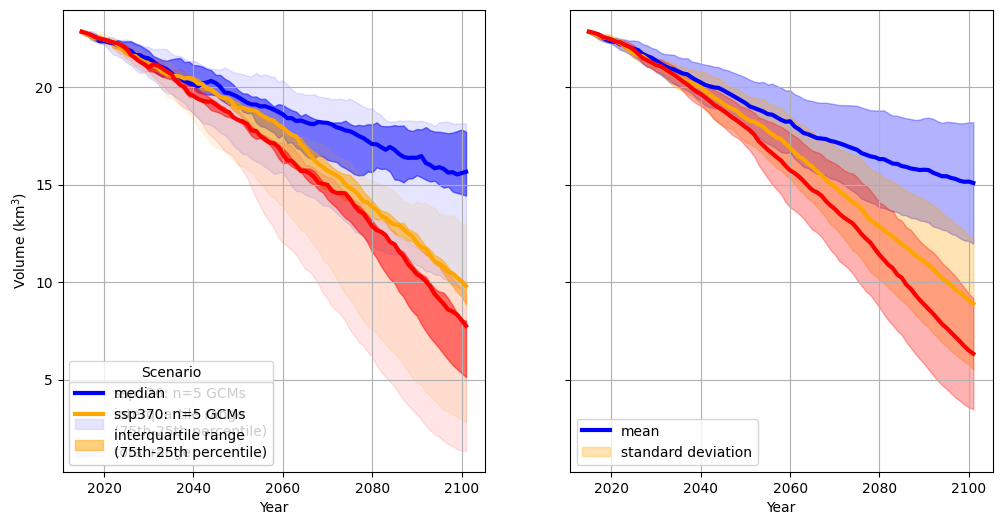

In [53]:
color_dict={'ssp126':'blue', 'ssp370':'orange', 'ssp585':'red'}


fig, axs = plt.subplots(1,2, figsize=(12,6), 
                        sharey=True # we want to share the y axis betweeen the subplots
                       )
for scenario in color_dict.keys():
    # get amount of GCMs per Scenario to add it to the legend:
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario)/1e9,  # m3 -> km3
                label=f'{scenario}: n={n} GCMs',
                color=color_dict[scenario],lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario)/1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario)/1e9,
                        color=color_dict[scenario],
                        alpha=0.5,
                        label='interquartile range\n(75th-25th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario)/1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario)/1e9,
                        color=color_dict[scenario],
                        alpha=0.1,
                        label='total range')


for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                 ds_total_volume_mean.sel(SCENARIO=scenario)/1e9,  # m3 -> km3
                 color=color_dict[scenario],
                 label='mean',lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario)/1e9 - ds_total_volume_std.sel(SCENARIO=scenario)/1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario)/1e9 + ds_total_volume_std.sel(SCENARIO=scenario)/1e9,
                        alpha=0.3,
                        color=color_dict[scenario],
                       label='standard deviation')
    
for ax in axs:
    # get all handles and labels and then create two different legends
    handles, labels = ax.get_legend_handles_labels()
    if ax == axs[0]:
        # we want to have two legends, let's save the first one
        # which just shows the colors and the different SSPs here 
        leg1 = ax.legend(handles[:3], labels[:3], title='Scenario') 
        ax.set_ylabel(r'Volume (km$^3$)')
        # create the second one, that shows the different statistical estimates
        ax.legend([handles[0],handles[3],handles[4]],
                  ['median',labels[3],labels[4]], loc='lower left')
        # we need to allow for two legend, this is done like that
        ax.add_artist(leg1)
    else:
        # for the second plot, we only want to have the legend for mean and std
        ax.legend(handles[::3], labels[::3], loc='lower left') 
    ax.set_xlabel('Year');
    ax.grid()

Text(0.5, 1.0, 'ssp585')

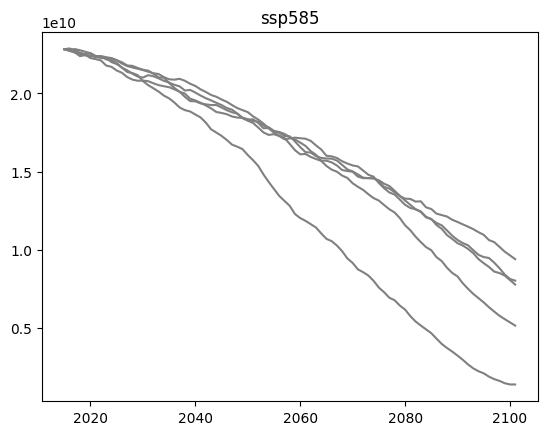

In [54]:
# for example, if there are just 5 GCMs, maybe you can just show all of them?
for gcm in all_GCM: 
    plt.plot(ds_total_volume.sel(SCENARIO=scenario).time,
            ds_total_volume.sel(SCENARIO=scenario, GCM=gcm),
             color='grey')
plt.title(scenario)

In [55]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


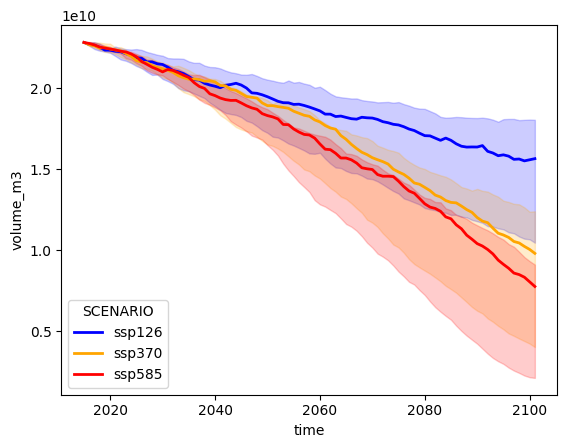

In [56]:
import seaborn as sns 
# this code might only work with seaborn v>=0.12
# seaborn always likes to have pandas dataframes
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()
sns.lineplot(x='time', y='volume_m3',
             hue='SCENARIO', # these are the dimension for the different colors 
             estimator='median', # here you could also choose the mean
             data=pd_total_volume,
             lw=2, # increase the linewidth a bit
             palette= color_dict, # let's use the same colors as before
             # for errorbar you could also choose another percentile range
             # see: https://seaborn.pydata.org/tutorial/error_bars.html
             # "90" means the range goes from the 5th to the 95th percentile
             # (50 would be the interquartile range, i.e., the same as two plots above)
             errorbar=('pi', 90) 
            );

In [57]:
pip install holoviews

Note: you may need to restart the kernel to use updated packages.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
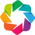

In [58]:
# Plotting
import holoviews as hv
import panel as pn
hv.extension('bokeh')
pn.extension()

In [59]:
def calculate_total_mean_and_std(ds, variable):
    mean = ds[variable].sum(dim='rgi_id',  # first sum up over all glaciers
                            skipna=True,
                            keep_attrs=True,
                            # important, need values for every glacier
                            min_count=len(ds_merged.rgi_id), 
                           ).mean(dim='GCM',  # afterwards calculate the mean of all GCMs
                                  skipna=True,
                                  keep_attrs=True,
                                 )
    std = ds[variable].sum(dim='rgi_id',  # first sum up over all glaciers 
                           skipna=True,
                           keep_attrs=True,
                           min_count=len(ds_merged.rgi_id), 
                          ).std(dim='GCM',  # afterwards calculate the std of all GCMs
                                skipna=True,
                                keep_attrs=True,
                               )
    return mean, std

In [60]:
# calculate mean and std with the previously defined function
total_volume_mean, total_volume_std = calculate_total_mean_and_std(ds_merged, 'volume')

# select only one SSP scenario
total_volume_mean_ssp585 = total_volume_mean.loc[{'SCENARIO': 'ssp585'}]

# plot a curve
x = total_volume_mean_ssp585.coords['time']
y = total_volume_mean_ssp585
hv.Curve((x, y),
         kdims=x.name,
         vdims=y.name,
        ).opts(xlabel=x.attrs['description'],
               ylabel=f"{y.attrs['description']} in {y.attrs['unit']}")

:Curve   [time]   (volume)

In [61]:
def get_single_curve(mean, std, ssp):
    color = color_dict[ssp] 
    mean_use = mean.loc[{'SCENARIO': ssp}]  # read out the mean of the SSP to plot 
    std_use = std.loc[{'SCENARIO': ssp}]  # read out the std of the SSP to plot
    time = mean.coords['time']  # get the time for the x axis
    
    return (hv.Area((time,  # plot std as an area
                     mean_use + std_use,  # upper boundary of the area
                     mean_use - std_use),  # lower boundary of the area
                    vdims=[mean_use.name, 'y2'],  # vdims for both boundaries
                    kdims='time',
                    label=ssp,
                   ).opts(alpha=0.2,
                          line_color=None,
                         ) *
            hv.Curve((time, mean_use),
                     vdims=mean_use.name,
                     kdims='time',
                     label=ssp,
                     
                    ).opts(line_color=color)
           ).opts(width=400,  # width of the total plot
                  height=400,  # height of the total plot
                  xlabel=time.attrs['description'],
                  ylabel=f"{mean_use.attrs['description']} in {mean_use.attrs['unit']}",
                 )

In [62]:
def overlay_scenarios(ds, variable):
    hmap = hv.HoloMap(kdims='Scenarios')   # create a HoloMap
    mean, std = calculate_total_mean_and_std(ds, variable)  # calculate mean and std for all SSPs using our previously defined function
    for ssp in all_scenario:
        hmap[ssp] = get_single_curve(mean, std, ssp)  # add a curve for each SSP to the HoloMap, using the SSP as a key (when you compare it do a dictonary)
    return hmap.overlay().opts(title=variable)  # create an overlay of all curves

In [63]:
all_plots = pn.Column(pn.Row(overlay_scenarios(ds_merged, 'volume'),
                             overlay_scenarios(ds_merged, 'area'),
                            ),
                      overlay_scenarios(ds_merged, 'melt_on_glacier'))

/home/usman/anaconda3/envs/oggm_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [64]:
all_plots

Column
    [0] Row
        [0] HoloViews(NdOverlay, height=400, sizing_mode='fixed', width=400)
        [1] HoloViews(NdOverlay, height=400, sizing_mode='fixed', width=400)
    [1] HoloViews(NdOverlay, height=400, sizing_mode='fixed', width=400)

In [65]:
all_plots.show()

Launching server at http://localhost:43483


In [66]:
plots_to_save = pn.panel(all_plots)
plots_to_save.save('GCM_runs.html', embed=True)